In [1]:
import os
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import time
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torchinfo import summary 
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Found! Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("No GPU found → Running on CPU (will be slower)")

torch.cuda.empty_cache()

GPU Found! Using: NVIDIA GeForce RTX 3050 Ti Laptop GPU
CUDA Version: 11.8
Memory Allocated: 0.0 GB


In [ ]:
filename = 'business+economy.csv'
df = pd.read_csv(filename)

data = df.drop(columns=['index', 'flight', 'Unnamed: 0'], 
               errors='ignore').copy()

print(f"Dataset shape: {data.shape}")
print(data.head())

Dataset shape: (300153, 10)
    airline source_city departure_time stops   arrival_time destination_city  \
0  SpiceJet       Delhi        Evening  zero          Night           Mumbai   
1  SpiceJet       Delhi  Early_Morning  zero        Morning           Mumbai   
2   AirAsia       Delhi  Early_Morning  zero  Early_Morning           Mumbai   
3   Vistara       Delhi        Morning  zero      Afternoon           Mumbai   
4   Vistara       Delhi        Morning  zero        Morning           Mumbai   

     class  duration  days_left  price  
0  Economy      2.17          1   5953  
1  Economy      2.33          1   5953  
2  Economy      2.17          1   5956  
3  Economy      2.25          1   5955  
4  Economy      2.33          1   5955  


In [4]:
#check missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [5]:
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
X = data.drop(['price'], axis=1)
Y = data['price'].values
Y_log = np.log1p(Y)


In [7]:
nominalFeatures  = ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
oneHotPipe = Pipeline([('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

ordinalFeatures = ['class', 'stops']
classCategory = ['Business', 'Economy']
stopsCategory = ['zero', 'one', 'two_or_more']
ordinalPipe = Pipeline([('ordinal', OrdinalEncoder(categories=[classCategory,stopsCategory]))])

numericalFeatures = ['duration', 'days_left']
numPipe = Pipeline([('scaler', StandardScaler())])

preprocessor = ColumnTransformer([
    ('nom', oneHotPipe, nominalFeatures),
    ('ord', ordinalPipe, ordinalFeatures),
    ('num', numPipe, numericalFeatures)
], remainder='drop')

In [8]:
X_train_raw, X_test_raw, Y_train_log, Y_test_log = train_test_split(X, Y_log, test_size =0.3, random_state=42, shuffle=True)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

X_train_t = torch.FloatTensor(X_train_processed).to(device)       
X_test_t  = torch.FloatTensor(X_test_processed).to(device)
Y_train_t = torch.FloatTensor(Y_train_log).reshape(-1, 1).to(device)
Y_test_t  = torch.FloatTensor(Y_test_log).reshape(-1, 1).to(device)

print(f"Training samples   : {X_train_t.shape[0]:,}")
print(f"Testing samples    : {X_test_t.shape[0]:,}")
print(f"Number of Features : {X_train_t.shape[1]}")


Training samples   : 210,107
Testing samples    : 90,046
Number of Features : 29


In [9]:
onehot_encoder = preprocessor.named_transformers_['nom'].named_steps['onehot']
oneHotFeatures = onehot_encoder.get_feature_names_out(nominalFeatures)

allFeaturesNamed = list(oneHotFeatures) + ordinalFeatures + numericalFeatures
print(f"\nTotal features: {len(allFeaturesNamed)}")
print('=' * 50)

for i, name in enumerate(allFeaturesNamed):
    print(f"{i+1:2d}.  {name}")
    
print('=' * 50)


Total features: 29
 1.  airline_Air_India
 2.  airline_GO_FIRST
 3.  airline_Indigo
 4.  airline_SpiceJet
 5.  airline_Vistara
 6.  source_city_Chennai
 7.  source_city_Delhi
 8.  source_city_Hyderabad
 9.  source_city_Kolkata
10.  source_city_Mumbai
11.  destination_city_Chennai
12.  destination_city_Delhi
13.  destination_city_Hyderabad
14.  destination_city_Kolkata
15.  destination_city_Mumbai
16.  departure_time_Early_Morning
17.  departure_time_Evening
18.  departure_time_Late_Night
19.  departure_time_Morning
20.  departure_time_Night
21.  arrival_time_Early_Morning
22.  arrival_time_Evening
23.  arrival_time_Late_Night
24.  arrival_time_Morning
25.  arrival_time_Night
26.  class
27.  stops
28.  duration
29.  days_left


In [10]:
print(f"X_train_t : ({X_train_t.shape[0]},{X_train_t.shape[1]})")
print(f"Y_train_t : ({Y_train_t.shape[0]},{Y_train_t.shape[1]})")
print(f"X_test_t  : ({X_test_t.shape[0]},{X_test_t.shape[1]})")
print(f"Y_test_t  : ({Y_test_t.shape[0]},{Y_test_t.shape[1]})")

X_train_t : (210107,29)
Y_train_t : (210107,1)
X_test_t  : (90046,29)
Y_test_t  : (90046,1)


In [11]:
class FlightPriceNet(nn.Module):
    def __init__(self, input_size, dropout=0.4):
        super(FlightPriceNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.model(x)

In [12]:
input_size = X_train_t.shape[1]
model = FlightPriceNet(input_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

train_dataset = TensorDataset(X_train_t, Y_train_t)
test_dataset  = TensorDataset(X_test_t,  Y_test_t)

batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [13]:
num_epochs = 300
best_val_loss = float('inf')
patience = 15
wait = 0

for epoch in tqdm(range(num_epochs), desc="Overall Training Progress", position=0, leave=True):
    
    model.train()
    train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for batch_x, batch_y in train_pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
        train_pbar.set_postfix({'loss': f'{loss.item():.5f}'})
    
    train_loss /= len(train_loader.dataset)
    train_pbar.close()
    
    model.eval()
    val_loss = 0.0
    
    val_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for batch_x, batch_y in val_pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            
            val_pbar.set_postfix({'loss': f'{loss.item():.5f}'})
    
    val_loss /= len(test_loader.dataset)
    val_pbar.close()
    
    scheduler.step(val_loss)
    
    tqdm.write(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")
    

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            tqdm.write(f"Early stopping triggered at epoch {epoch+1}")
            break

print(f"\nTraining finished! Best validation loss: {best_val_loss:.5f}")

Overall Training Progress:   0%|          | 1/300 [00:07<38:17,  7.69s/it]

Epoch   1 | Train Loss: 47.22048 | Val Loss: 18.07185


Overall Training Progress:   1%|          | 2/300 [00:15<38:40,  7.79s/it]

Epoch   2 | Train Loss: 5.51214 | Val Loss: 0.48278


Overall Training Progress:   1%|          | 3/300 [00:23<39:33,  7.99s/it]

...

Epoch 156 | Train Loss: 0.03985 | Val Loss: 0.03379


Overall Training Progress:  52%|█████▏    | 157/300 [22:33<20:11,  8.47s/it]

Epoch 157 | Train Loss: 0.04007 | Val Loss: 0.03284


Overall Training Progress:  52%|█████▏    | 157/300 [22:41<20:40,  8.67s/it]

Epoch 158 | Train Loss: 0.03955 | Val Loss: 0.03308
Early stopping triggered at epoch 158

Training finished! Best validation loss: 0.03275


In [14]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_pred_log = []

with torch.no_grad():
    for batch_x, _ in tqdm(test_loader, desc="Generating All Predictions"):
        batch_x = batch_x.to(device)
        batch_pred = model(batch_x).cpu().numpy()
        y_pred_log.extend(batch_pred.flatten())

y_pred_log = np.array(y_pred_log)

y_pred_original = np.expm1(y_pred_log)         
y_true_original = np.expm1(Y_test_log)          

results_df = pd.DataFrame({
    'Actual_Price': y_true_original,
    'Predicted_Price': y_pred_original,
    'Absolute_Error': np.abs(y_true_original - y_pred_original)
})

results_df = results_df.round(2)

mae  = mean_absolute_error(y_true_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
r2   = r2_score(y_true_original, y_pred_original)

print(f"\nFinal Model Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

print("="*80)

print("First 20 predictions:")
display(results_df.head(20)) 

print("\nLast 20 predictions:")
display(results_df.tail(20))

print("\nError Statistics:")
print(results_df['Absolute_Error'].describe())

results_df.to_csv('flight_price_all_predictions.csv', index_label='Test_Index')

Generating All Predictions: 100%|██████████| 88/88 [00:01<00:00, 55.74it/s]


Final Model Performance:
MAE:  2099.93
RMSE: 4125.17
R²:   0.9669
First 20 predictions:


,Actual_Price,Predicted_Price,Absolute_Error
0,7366.0,5772.910156,1593.09
1,64831.0,65050.421875,219.43
2,6195.0,6882.720215,687.72
3,60160.0,56435.539062,3724.45
4,6578.0,6313.970215,264.03
5,4555.0,7003.759766,2448.76
6,23838.0,23200.000000,638.00
7,3860.0,3897.840088,37.84
8,32230.0,48985.511719,16755.51
9,76841.0,66244.382812,10596.63



Last 20 predictions:


,Actual_Price,Predicted_Price,Absolute_Error
90026,3999.0,3982.939941,16.06
90027,3024.0,3879.070068,855.07
90028,6324.0,6095.669922,228.33
90029,64113.0,62069.730469,2043.27
90030,12873.0,4724.700195,8148.30
90031,22140.0,21893.189453,246.81
90032,6817.0,6425.759766,391.23
90033,12557.0,12024.540039,532.46
90034,4478.0,6009.200195,1531.20
90035,6994.0,4995.500000,1998.50



Error Statistics:
count    90046.000000
mean      2099.928955
std       3550.702566
min          0.000000
25%        264.495000
50%        754.335000
75%       2259.977500
max      56620.290000
Name: Absolute_Error, dtype: float64


In [15]:
residuals = np.squeeze(np.array(y_true_original) - np.array(y_pred_original))

residuals_df = pd.DataFrame(residuals)

In [16]:
residuals_df.head()

,0
0,1593.093262
1,-219.425781
2,-687.717285
3,3724.453125
4,264.025391


In [17]:
residuals_df.describe()

,0
count,90046.000000
mean,663.154872
std,4071.542700
min,-32925.617188
25%,-548.804932
50%,5.848999
75%,1134.846191
max,56620.285156


In [18]:

for i in range(0, len(residuals)):
    residuals[i] = abs(residuals[i])

residuals_df_abs = pd.DataFrame(residuals)

residuals_df_abs.describe()

,0
count,90046.000000
mean,2099.928951
std,3550.702558
min,0.003906
25%,264.495361
50%,754.333740
75%,2259.974609
max,56620.285156


<Axes: title={'center': 'Residual Graph of Testing'}, xlabel='No. of Prediction', ylabel='Residual Magnitude'>

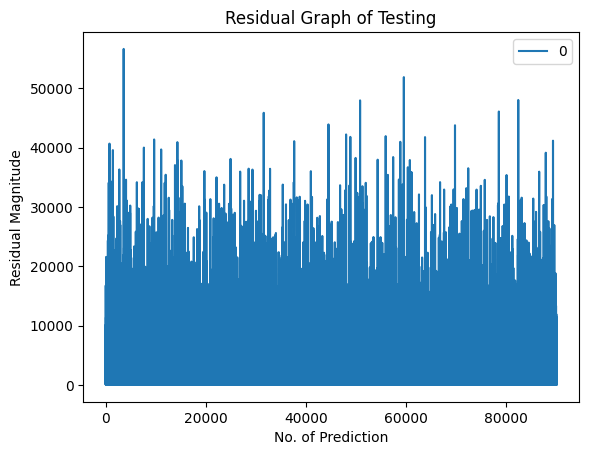

In [19]:
residuals_df.plot(title="Residual Graph of Testing",
                  xlabel="No. of Prediction",
                  ylabel="Residual Magnitude")

<Axes: title={'center': 'Residual Density Graph'}, ylabel='Density'>

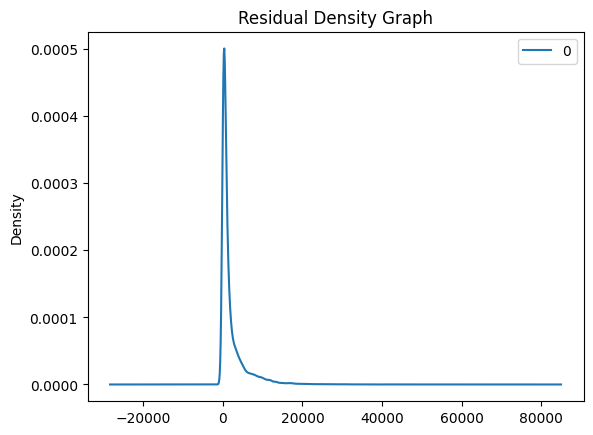

In [20]:
residuals_df.plot(kind='kde', title="Residual Density Graph")

In [40]:
print(y_true_original)
y_true_df = pd.DataFrame(y_true_original)
print(y_true_df)

print("\n\n")
print(y_true_original)
y_pred_df = pd.DataFrame(y_pred_original)
print(y_pred_df)

[ 7366. 64831.  6195. ...  2410.  2835.  3393.]
             0
0       7366.0
1      64831.0
2       6195.0
3      60160.0
4       6578.0
...        ...
90041   6134.0
90042  67004.0
90043   2410.0
90044   2835.0
90045   3393.0

[90046 rows x 1 columns]



[ 7366. 64831.  6195. ...  2410.  2835.  3393.]
                  0
0       5772.906738
1      65050.425781
2       6882.717285
3      56435.546875
4       6313.974609
...             ...
90041   5908.247070
90042  62702.175781
90043   2520.516602
90044   4045.674561
90045   3773.693359

[90046 rows x 1 columns]


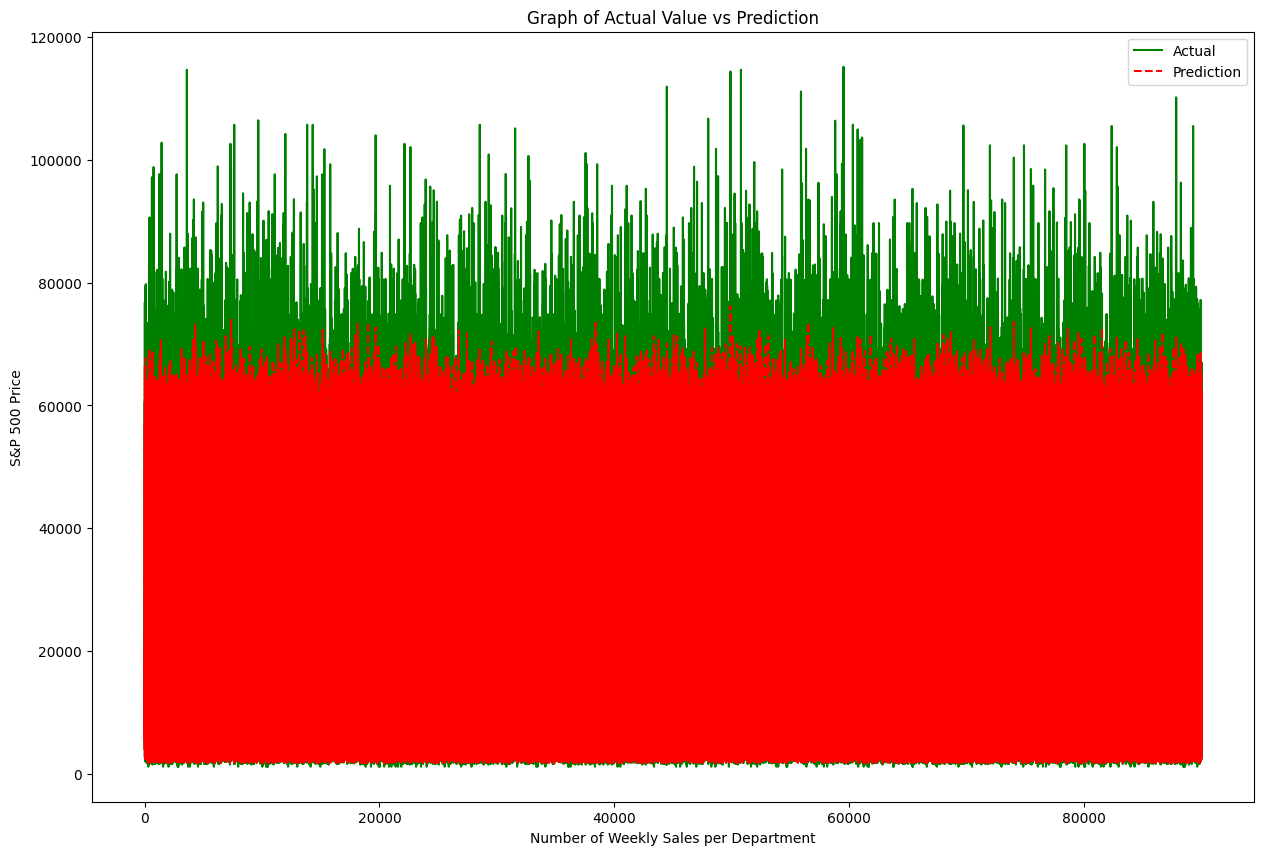

In [42]:
fig = plt.figure(figsize=(15, 10))

plt.plot(y_true_df.reset_index(drop=True), label="Actual", color='green')
plt.plot(y_pred_df, label="Prediction", color='red', linestyle='dashed')

plt.title("Graph of Actual Value vs Prediction")
plt.xlabel("Number of Weekly Sales per Department")
plt.ylabel("S&P 500 Price")

plt.legend()
plt.show()